# the MNIST dataset, which is a set of 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau. Each image is labeled with the digit it represents.

## Scikit-Learn provides many helper functions to download popular datasets. MNIST is one of them. The following code fetches the MNIST dataset:

In [14]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784' , version = 1)

mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [15]:
X = mnist['data']

X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
y = mnist['target']

y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [52]:
digit = X.iloc[0].values
digit_img = digit.reshape(28,28)

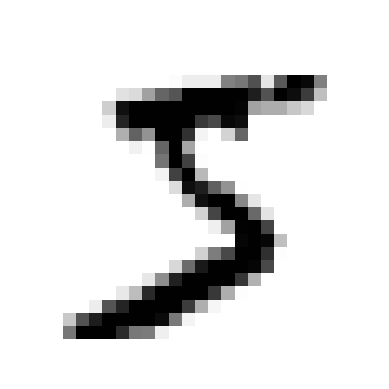

In [53]:
plt.imshow(digit_img , cmap='binary' , interpolation='nearest')
plt.axis('off')
plt.show()

In [18]:
import numpy as np;
import pandas as pd;

In [24]:
y = y.astype(dtype='int32')
y[0]

np.int32(5)

### The first 60000 are train set and last 10000 are test set

In [25]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

#### Let’s simplify the problem for now and only try to identify one digit—for example, the number 5. This “5-detector” will be an example of a binary classifier, capable of distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for this classification task:

In [26]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

#### Now let’s pick a classifier and train it. A good place to start is with a Stochastic Gradient Descent (SGD) classifier, using Scikit-Learn’s SGDClassifier class. This classifier has the advantage of being capable of handling very large datasets efficiently.

In [27]:
print(set(y_train))
print(y_train_5.value_counts())

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
class
False    54579
True      5421
Name: count, dtype: int64


In [28]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(X_train , y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


### Now we can use it to detect images of the number 5:

In [29]:
digit_df = pd.DataFrame([digit],columns=X_train.columns)
sgd_clf.predict(digit_df)

array([False])

## Performance Measures

### Measuring Accuracy Using Cross-Validation

### Implementing Cross-Validation

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
summ=0;
for train_index,test_index in skfolds.split(X_train , y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_fold , y_train_fold)
    y_pred = clone_clf.predict(X_test_fold)
    correct = sum(y_pred == y_test_fold)

    print(correct/len(y_pred))
    summ += correct/len(y_pred)

print("Average accuracy is : ",summ/3.0)

0.9669
0.91625
0.96785
Average accuracy is :  0.9503333333333334


### Let’s use the cross_val_score() function to evaluate our SGDClassifier model, using K-fold cross-validation with three folds.

In [31]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf , X_train, y_train_5 , cv = 3 , scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [32]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

y_train_pred

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [33]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5 , y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

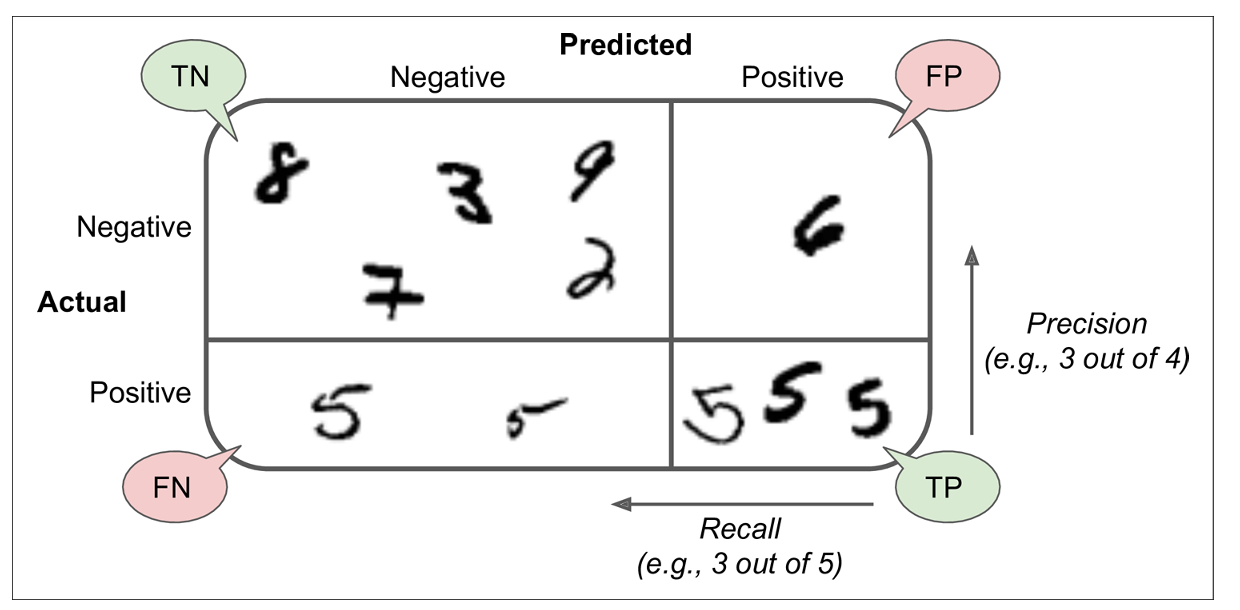

## Precision and Recall

In [37]:
from sklearn.metrics import precision_score,recall_score

precision_score(y_train_5 , y_train_pred)

0.8370879772350012

In [38]:
 recall_score(y_train_5, y_train_pred) 

0.6511713705958311

In [39]:
from sklearn.metrics import f1_score

f1_score(y_train_5 , y_train_pred)

0.7325171197343847

### Precision 
- Definition: Out of all predictions where model said “5”, how many were actually correct?

### Recall
- Definition: Out of all actual “5”, how many did the model correctly detect?

In [41]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

# The ROC Curve

- the ROC curve plots the true positive rate (another name for recall) against the false positive rate (FPR).

In [42]:
from sklearn.metrics import roc_curve

fpr,tpr,threshold = roc_curve(y_train_5,y_scores)

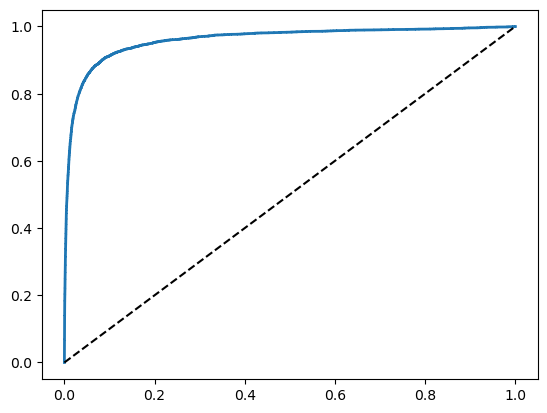

In [43]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
    [...] # Add axis labels and grid
plot_roc_curve(fpr, tpr)
plt.show()

In [44]:
confusion_matrix(y_train , y_train_pred)

array([[5860,   63,    0,    0,    0,    0,    0,    0,    0,    0],
       [6675,   67,    0,    0,    0,    0,    0,    0,    0,    0],
       [5932,   26,    0,    0,    0,    0,    0,    0,    0,    0],
       [5913,  218,    0,    0,    0,    0,    0,    0,    0,    0],
       [5821,   21,    0,    0,    0,    0,    0,    0,    0,    0],
       [1891, 3530,    0,    0,    0,    0,    0,    0,    0,    0],
       [5796,  122,    0,    0,    0,    0,    0,    0,    0,    0],
       [6251,   14,    0,    0,    0,    0,    0,    0,    0,    0],
       [5741,  110,    0,    0,    0,    0,    0,    0,    0,    0],
       [5903,   46,    0,    0,    0,    0,    0,    0,    0,    0]])

## Multilabel Classification

In [46]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train %2 == 1)

y_multilabel = np.c_[y_train_large,y_train_odd]

In [50]:
knn_clf = KNeighborsClassifier()

knn_clf.fit(X_train , y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [58]:
knn_clf.predict(digit_df)

array([[False, False]])

In [59]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [60]:
y_train_knn_pred

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]], shape=(60000, 2))

In [64]:
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

## Multioutput Classification

In [65]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test